In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import quaia
from astropy.coordinates import SkyCoord

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

In [3]:
cmap_map = 'plasma'

# Load data from local machine

In [4]:
fn_gcatlo = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock1.fits'
fn_gcathi = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20.5/mock_catalog_quaia_G20.5_mock1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
name_catalog = '$Gaia$-$unWISE$ Quasar Mock Catalog'
abbrv_catalog = 'Quaia'

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
# for plotting purposes
fac_stdev = 0.5 # 1.45 # 1.5

## Quasar mock catalog

In [10]:
tab_gcatlo = Table.read(fn_gcatlo)
N_gcatlo = len(tab_gcatlo)
print(f"Number of data sources: {N_gcatlo}")

Number of data sources: 755512


In [11]:
print(tab_gcatlo.meta)

OrderedDict()


In [12]:
print(f"Column names: {tab_gcatlo.columns}")

Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


In [13]:
tab_gcathi = Table.read(fn_gcathi)
N_gcathi = len(tab_gcathi)
print(f"Number of data sources: {N_gcathi}")

Number of data sources: 1295221


### Make map of quasar number counts

In [14]:
# mask the plane
mask = 30 #20
c_gcatlo = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree)
mask_gcatlo = np.abs(c_gcatlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcatlo_mask = len(tab_gcatlo['ra'][mask_gcatlo])

In [15]:
pixel_indices_gcatlo_mask = hp.ang2pix(NSIDE, tab_gcatlo['ra'][mask_gcatlo], tab_gcatlo['dec'][mask_gcatlo], lonlat=True)
map_gcatlo = np.bincount(pixel_indices_gcatlo_mask, minlength=NPIX)

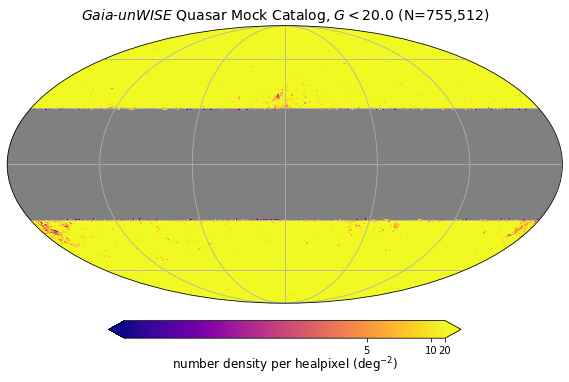

In [16]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_gcatlo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.median(map_gcatlo)+fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [17]:
c_gcathi = SkyCoord(ra=tab_gcathi['ra']*u.degree, dec=tab_gcathi['dec']*u.degree)
mask_gcathi = np.abs(c_gcathi.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcathi_mask = len(tab_gcathi['ra'][mask_gcathi])

In [18]:
pixel_indices_gcathi_mask = hp.ang2pix(NSIDE, tab_gcathi['ra'][mask_gcathi], tab_gcathi['dec'][mask_gcathi], lonlat=True)
map_gcathi = np.bincount(pixel_indices_gcathi_mask, minlength=NPIX)

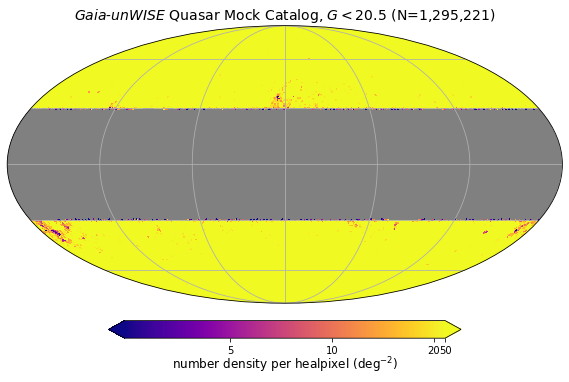

In [19]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_gcathi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi)-fac_stdev*np.std(map_gcathi), max=np.median(map_gcathi)+fac_stdev*np.std(map_gcathi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 50])

## Random catalog

In [20]:
tab_randlo = Table.read(fn_randlo)
N_randlo = len(tab_randlo)
print(f"Number of random sources: {N_randlo}")

Number of random sources: 7563151


In [21]:
print(f"Column names: {tab_randlo.columns}")

Column names: <TableColumns names=('ra','dec','ebv')>


In [22]:
tab_randhi = Table.read(fn_randhi)
N_randhi = len(tab_randhi)
print(f"Number of random sources: {N_randhi}")

Number of random sources: 12955802


### Make maps of random number counts

In [23]:
c_randlo = SkyCoord(ra=tab_randlo['ra'], dec=tab_randlo['dec'])
mask_randlo = np.abs(c_randlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_randlo_mask = len(tab_randlo['ra'][mask_randlo])

In [24]:
pixel_indices_randlo_mask = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo], tab_randlo['dec'][mask_randlo], lonlat=True)
map_randlo = np.bincount(pixel_indices_randlo_mask, minlength=NPIX)

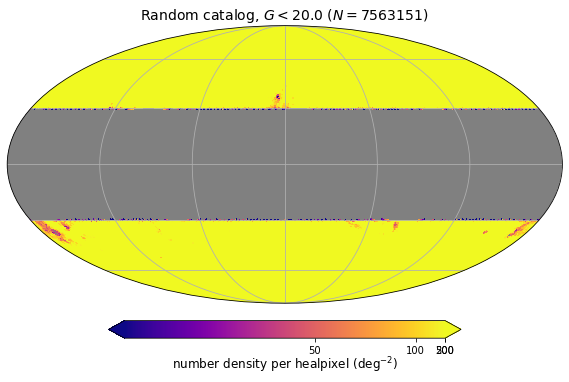

In [25]:
projview(map_randlo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randlo)-fac_stdev*np.std(map_randlo), 
            max=np.median(map_randlo)+fac_stdev*np.std(map_randlo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 100, 200, 500]) 

In [26]:
c_randhi = SkyCoord(ra=tab_randhi['ra'], dec=tab_randhi['dec'])
mask_randhi = np.abs(c_randhi.galactic.b.value)>=mask # use galactic coordinates from data 
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])

In [27]:
pixel_indices_randhi_mask = hp.ang2pix(NSIDE, tab_randhi['ra'][mask_randhi], tab_randhi['dec'][mask_randhi], lonlat=True)
map_randhi = np.bincount(pixel_indices_randhi_mask, minlength=NPIX)

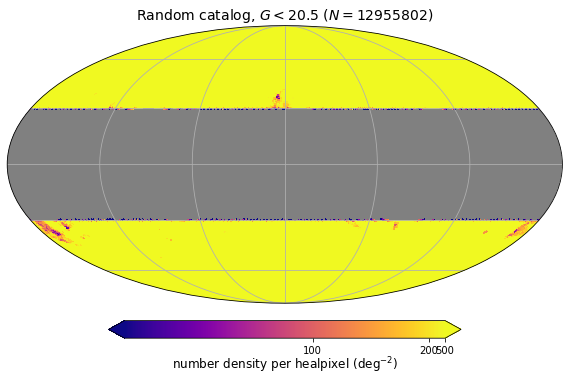

In [28]:
projview(map_randhi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randhi)-fac_stdev*np.std(map_randhi), max=np.median(map_randhi)+fac_stdev*np.std(map_randhi), 
            norm='log', graticule=True,
            cbar_ticks=[100, 200, 500]) 

## Remove the selection function
### Start with mock catalogs

In [29]:
selfunc_lo = hp.fitsfunc.read_map(fn_sello)

In [30]:
map_selfunc_lo = map_gcatlo/selfunc_lo

<ipython-input-30-22c4d4b7cd3d>:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


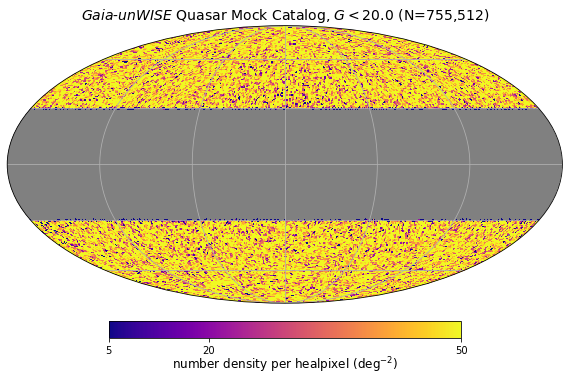

In [31]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_selfunc_lo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_lo)-fac_stdev*np.nanstd(map_selfunc_lo), max=np.nanmedian(map_selfunc_lo)+fac_stdev*np.nanstd(map_selfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 20, 50]) 

In [32]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [33]:
map_selfunc_hi = map_gcathi/selfunc_hi

<ipython-input-33-959af77865e4>:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_hi = map_gcathi/selfunc_hi


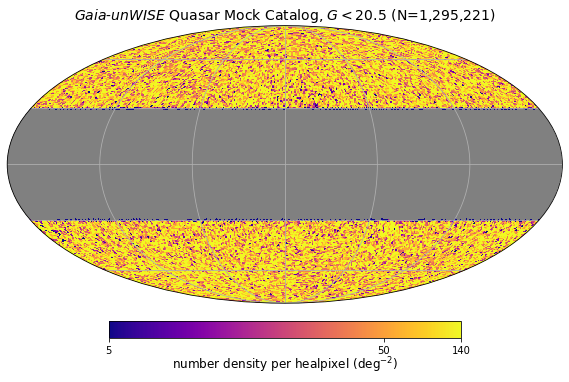

In [34]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_selfunc_hi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_hi)-fac_stdev*np.nanstd(map_selfunc_hi), max=np.nanmedian(map_selfunc_hi)+fac_stdev*np.nanstd(map_selfunc_hi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 50, 140]) 

### Now random catalog

In [35]:
map_randselfunc_lo = map_randlo/selfunc_lo

<ipython-input-35-8958bc3fcfda>:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_lo = map_randlo/selfunc_lo


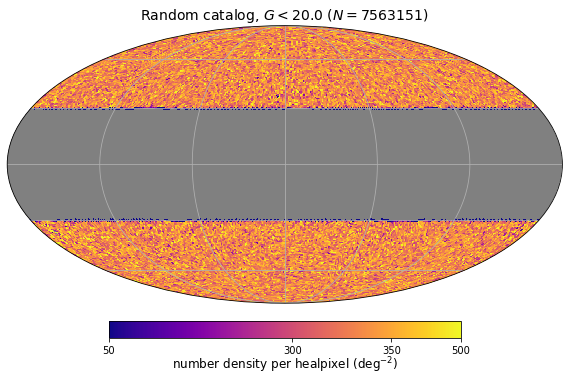

In [36]:
projview(map_randselfunc_lo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_randselfunc_lo)-fac_stdev*np.nanstd(map_randselfunc_lo), 
            max=np.nanmedian(map_randselfunc_lo)+fac_stdev*np.nanstd(map_randselfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 300, 350, 500]) 

In [37]:
map_randselfunc_hi = map_randhi/selfunc_hi

<ipython-input-37-cd4f1c307f04>:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_hi = map_randhi/selfunc_hi


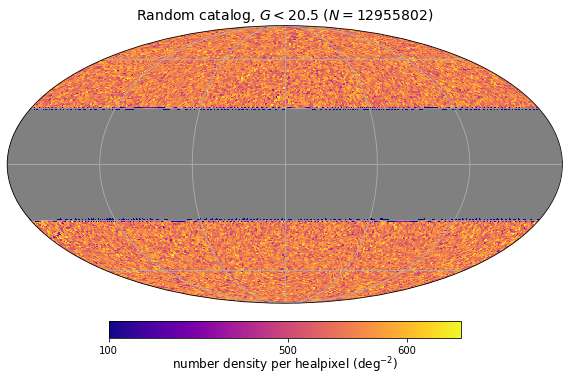

In [38]:
projview(map_randselfunc_hi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
         unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_randselfunc_hi)-fac_stdev*np.nanstd(map_randselfunc_hi), 
         max=np.nanmedian(map_randselfunc_hi)+fac_stdev*np.nanstd(map_randselfunc_hi), norm='log', graticule=True, 
         cbar_ticks=[100, 500, 600]) 

# Plot the $n(z)$ distribution

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
0.2766828634345089 6.0 11.446634273130982


/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py:58: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


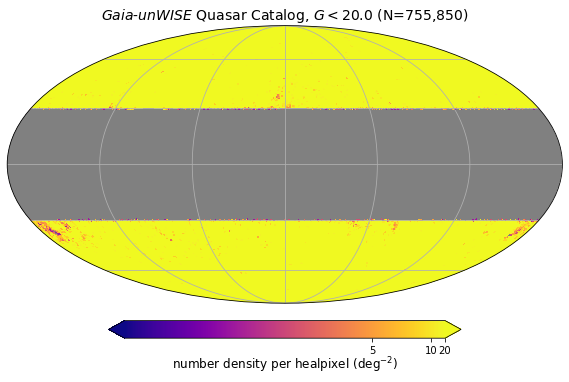

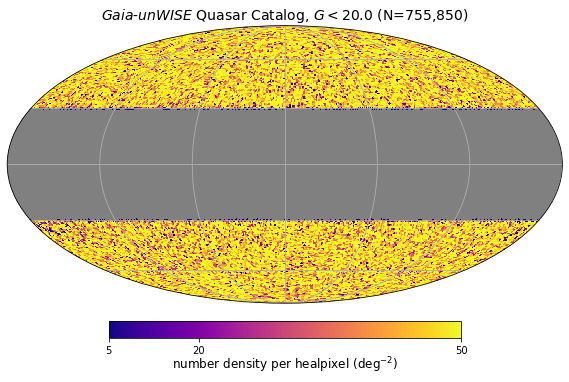

In [41]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', '$Gaia$-$unWISE$ Quasar Catalog', G_lo, 
                                                                               fn_sello, mask = mask, fac_stdev = fac_stdev)

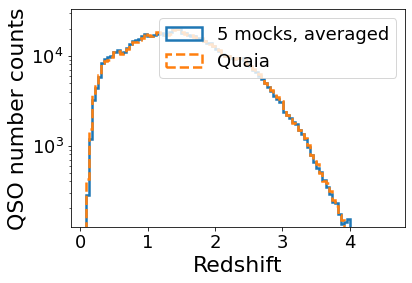

In [42]:
mean = []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,6):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i = Table.read(fn_gcatlo_i)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
plt.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', label = '5 mocks, averaged', linewidth = 2.5)
plt.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, linestyle = '--', linewidth = 2.5)
plt.xlabel('Redshift')
plt.ylabel('QSO number counts')
plt.yscale('log')
plt.ylim(125,)
plt.legend()
plt.show()

## See the impact of masking

In [43]:
mean, mean_mask = [], []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,6):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, '$Gaia$-$unWISE$ Quasar Catalog', G_lo, 
                                                                                           fn_sello, plot = False, mask = mask)
    # tab_gcatlo_i = Table.read(fn_gcatlo_i)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
    # try it wth the mask
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'][mask_gcatlo_i], bins = bins)
    mean_mask.append(hist)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


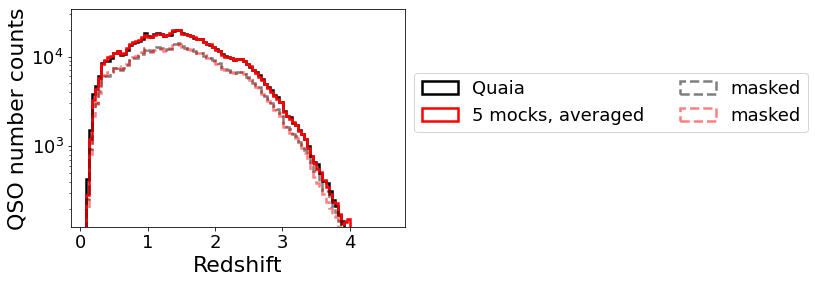

In [44]:
n_data, bins_data, patches_data = plt.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, linewidth = 2.5, 
                                           color = 'black')
n_mock, bins_mock, patches_mock = plt.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', label = '5 mocks, averaged', 
                                         linewidth = 2.5, color = 'red')
n_data_mask, bins_data_mask, patches_data_mask = plt.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', label = 'masked', 
                                                          bins = bins, linewidth = 2.5, linestyle = '--', color = 'black', alpha = 0.5)
n_mock_mask, bins_mock_mask, patches_mock_mask = plt.hist(bins[:-1], bins, weights = np.mean(mean_mask, axis = 0), histtype = 'step', 
                                                          label = 'masked', linewidth = 2.5, color = 'red', linestyle = '--', 
                                                          alpha = 0.5)
plt.xlabel('Redshift')
plt.ylabel('QSO number counts')
plt.yscale('log')
plt.ylim(125,)
plt.legend(ncol = 2, bbox_to_anchor=(1, 0.25, 0.5, 0.5))
plt.show()

<ipython-input-45-67776c2f3512>:2: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(quaia.recenter(bins_data), n_mock_mask/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')


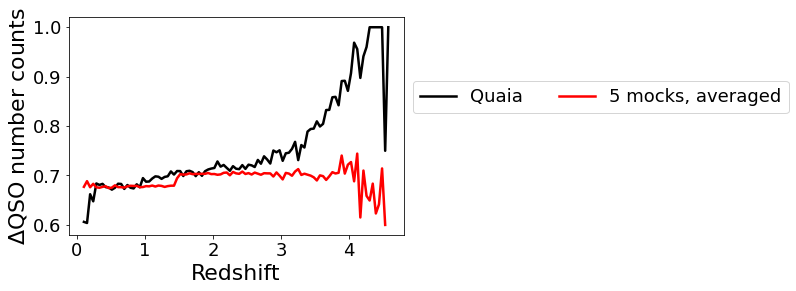

In [45]:
plt.plot(quaia.recenter(bins_data), n_data_mask/n_data, label = 'Quaia', linewidth = 2.5, color = 'black')
plt.plot(quaia.recenter(bins_data), n_mock_mask/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')
plt.xlabel('Redshift')
plt.ylabel('$\Delta$QSO number counts')
# plt.yscale('log')
# plt.ylim(125,)
plt.legend(ncol = 2, bbox_to_anchor=(1, 0.25, 0.5, 0.5))
plt.show()

# Compute the projected angular auto-power spectrum
## First convert redshift space to X, Y, Z coordinates

In [46]:
# h = 0.6844
# H0 = h*100 * u.km/u.s/u.Mpc

In [47]:
# def Mpc_h(comoving_r):
#     return (comoving_r*cu.littleh).to(u.Mpc, cu.with_H0(H0))/cu.littleh # equivalent to comoving_d*h

In [46]:
def convert(tab_gcatlo):
    
    # obtain r: The comoving distance along the line-of-sight between two objects remains constant with time for objects in the Hubble flow.
    # H0 = h*100 * u.km/u.s/u.Mpc
    # cosmo = FlatLambdaCDM(H0=H0, Om0=0.302)
    # comoving_r = cosmo.comoving_distance(z)
    # r = Mpc_h(comoving_r) # convert from Mpc to Mpc/h
    
    ra = np.radians(tab_gcatlo['ra'].value)
    dec = np.radians(tab_gcatlo['dec'].value)
    r = quaia.comoving_dist(tab_gcatlo['redshift_quaia'])
    
    # convert degrees to radians
    # deg_to_rad = 2*np.pi/360 # radians/degrees
    return r*np.cos(dec)*np.cos(ra), r*np.cos(dec)*np.sin(ra), r*np.sin(dec)

In [48]:
# np.mean([np.max(i.value)-np.min(i.value) for i in [X1, Y1, Z1, X2, Y2, Z2]])/2
# correction = np.min([np.min(i.value) for i in [X1, Y1, Z1, X2, Y2, Z2]])
correction = -5205.182232081812

In [49]:
# X1, Y1, Z1 = convert(tab_gcatlo)

c = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree, distance=quaia.comoving_dist(tab_gcatlo['redshift_quaia']))
# X1, Y1, Z1 = c.cartesian.xyz.value
X1, Y1, Z1 = c.cartesian.xyz.value-correction

## Now measure the pair counts

In [50]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 150.0 # 20.0 #50.0
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

# # linear binning
# rmin = 0 # 0.1 # start higher
# rmax = 130 # 20.0 #50.0
# nbins = 13
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

In [51]:
# refer to https://en.wikipedia.org/wiki/Hubble%27s_law#Dimensionless_Hubble_constant
DD_counts, api_time = theory.DD(autocorr = 1, nthreads = 8, binfile = rbins, periodic = False,
                                X1 = X1[mask_gcatlo], Y1 = Y1[mask_gcatlo], Z1 = Z1[mask_gcatlo], weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], 
                                weight_type='pair_product', 
                                output_ravg = True, c_api_timer = True) # cz/H0 = Mpc/h = m/s * km/1000 m / (100 km/s/Mpc h)

# np.save('../results/theory_DD_counts_rmin{}_rmax{}_sel_mocks'.format(str(rmin), str(rmax)), DD_counts)
api_time

0.41699700000000006

### Generate a $z$ distribution for the random catalog
#### Try interpolating the cdf so it's more smooth

In [52]:
# def z_dist(tab_gcatlo, tab_randlo, mask_gcatlo, mask_randlo, N_gcatlo_mask, N_randlo_mask, mask = 20, plot = False):
    
#     # Compute the empirical cumulative distribution function (ECDF)
#     z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])
#     ecdf = np.arange(N_gcatlo_mask) / (N_gcatlo_mask - 1)

#     # Create an interpolation function for inverse transform sampling
#     inv_ecdf = interp.interp1d(ecdf, z) # have to interpolate, can't do binning method because each point --> cdf probability

#     # set random seed: https://builtin.com/data-science/numpy-random-seed
#     rng = np.random.default_rng(2023)
    
#     if plot == True:
        
#         plt.plot(z, ecdf, label = 'ecdf')
#         plt.hist(tab_gcatlo['redshift_quaia'][mask_gcatlo], cumulative = True, density = True, bins = 100)
#         plt.xlabel('$z$')
#         plt.legend()
#         plt.show()

#     # Generate new random samples from the estimated distribution
#     # return inv_ecdf(rng.random(size = N_randlo_mask))
#     tab_randlo['redshift_quaia_'+str(mask)] = -1.0
#     tab_randlo['redshift_quaia_'+str(mask)][mask_randlo] = inv_ecdf(rng.random(size = N_randlo_mask))

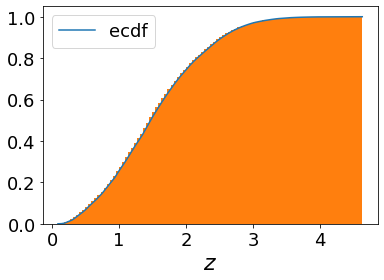

In [55]:
# # Compute the empirical cumulative distribution function (ECDF)
# z = np.sort(tab_gcatlo['redshift_quaia'][mask_gcatlo])
# ecdf = np.arange(N_gcatlo_mask) / (N_gcatlo_mask - 1)

# # Create an interpolation function for inverse transform sampling
# inv_ecdf = interp.interp1d(ecdf, z) # have to interpolate, can't do binning method because each point --> cdf probability

# # set random seed: https://builtin.com/data-science/numpy-random-seed
# rng = np.random.default_rng(2023)

# # Generate new random samples from the estimated distribution
# tab_randlo['redshift_quaia'] = -1.0
# tab_randlo['redshift_quaia'][mask_randlo] = inv_ecdf(rng.random(size = N_randlo_mask))

# tab_randlo['redshift_quaia'] = -1.0
# tab_randlo['redshift_quaia'][mask_randlo] = z_dist(tab_datalo, mask_datalo, N_datalo_mask, N_randlo_mask, plot = True)

quaia.z_dist(tab_datalo, tab_randlo, mask_datalo, mask_randlo, N_datalo_mask, N_randlo_mask, plot = True, mask = mask)

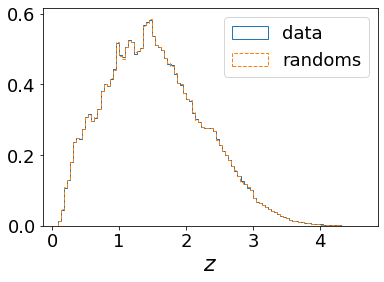

In [56]:
plt.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', density = True, label = 'data', bins = 100)
plt.hist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo], histtype = 'step', density = True, label = 'randoms', bins = 100, linestyle = '--')
plt.xlabel('$z$')
plt.legend()
plt.show()

In [57]:
# X2, Y2, Z2 = convert(tab_randlo['ra'], tab_randlo['dec'], tab_randlo['redshift_quaia'])
c = SkyCoord(ra=tab_randlo['ra'][mask_randlo], dec=tab_randlo['dec'][mask_randlo], 
             distance=quaia.comoving_dist(tab_randlo['redshift_quaia_'+str(mask)][mask_randlo]))
# X2, Y2, Z2 = c.cartesian.xyz
X2, Y2, Z2 = c.cartesian.xyz.value-correction

### Now measure clustering in random catalog

In [58]:
DR_counts, api_time = theory.DD(autocorr = 0, nthreads = 8, binfile = rbins, periodic = False,
                                X1 = X1[mask_gcatlo], Y1 = Y1[mask_gcatlo], Z1 = Z1[mask_gcatlo], weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], 
                                X2 = X2, Y2 = Y2, Z2 = Z2,
                                weights2 = 1/selfunc_lo[pixel_indices_randlo_mask], weight_type='pair_product', output_ravg = True, 
                                c_api_timer = True)

# np.save('../results/theory_DR_counts_rmin{}_rmax{}_sel_mocks'.format(str(rmin), str(rmax)), DR_counts)
api_time

1.945599

In [59]:
RR_counts, api_time = theory.DD(autocorr = 1, nthreads = 8, binfile = rbins, periodic = False,
                                X1 = X2, Y1 = Y2, Z1 = Z2, weights1 = 1/selfunc_lo[pixel_indices_randlo_mask], 
                                weight_type='pair_product',
                                output_ravg = True, c_api_timer = True)

# np.save('../results/theory_RR_counts_rmin{}_rmax{}_sel_mocks'.format(str(rmin), str(rmax)), RR_counts)
api_time

4.382226

### Plot for sanity check

In [60]:
DD_counts['npairs'] = DD_counts['npairs']*DD_counts['weightavg']
DR_counts['npairs'] = DR_counts['npairs']*DR_counts['weightavg']
RR_counts['npairs'] = RR_counts['npairs']*RR_counts['weightavg']

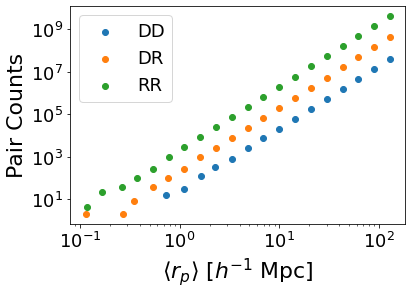

In [61]:
plt.scatter(DD_counts['ravg'], DD_counts['npairs'], label = 'DD')
plt.scatter(DR_counts['ravg'], DR_counts['npairs'], label = 'DR')
plt.scatter(RR_counts['ravg'], RR_counts['npairs'], label = 'RR')
plt.xlabel(r'$\langle r_{p}\rangle$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("Pair Counts")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Now convert the 2-D Pair counts into a $xi(r)$


In [62]:
# All the pair counts are done, get the angular correlation function
cf = convert_3d_counts_to_cf(N_gcatlo_mask, N_gcatlo_mask, N_randlo_mask, N_randlo_mask,
                                DD_counts, DR_counts,
                                DR_counts, RR_counts)

# np.save('../results/cf_rmin{}_rmax{}_sel_mocks'.format(str(rmin), str(rmax)), cf)
# np.save('../results/ravg_rmin{}_rmax{}_sel_mocks'.format(str(rmin), str(rmax)), DD_counts['ravg'])

<ipython-input-63-f289e911e73d>:9: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-3, 10)


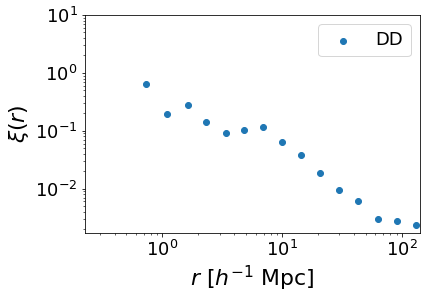

In [63]:
plt.scatter(DD_counts['ravg'], cf, label = 'DD')
# plt.scatter(DR_counts['ravg'], cf, label = 'DR')
# plt.scatter(RR_counts['ravg'], cf, label = 'RR')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylim(-3, 10)
plt.xlim(rmin+0.125, rmax-10)
plt.show()

### Compare to data

In [64]:
# X2, Y2, Z2 = c.cartesian.xyz
# pixel_indices_gcatlo = hp.ang2pix(NSIDE, tab_gcatlo['ra'], tab_gcatlo['dec'], lonlat=True)
# pixel_indices_randlo = hp.ang2pix(NSIDE, tab_randlo['ra'], tab_randlo['dec'], lonlat=True)

In [65]:
cf_mock, ravg_mock = quaia.xi_r(tab_gcatlo[mask_gcatlo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask, pixel_indices_randlo_mask, 
                                N_gcatlo_mask, N_randlo_mask, RR_counts, correction, rbins = rbins, mask = mask)

/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py:209: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
  if RR_counts == None:


In [66]:
cf_data, ravg_data = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, pixel_indices_randlo_mask, 
                                N_datalo_mask, N_randlo_mask, RR_counts, correction, rbins = rbins, mask = mask)

In [67]:
cf_data_test, ravg_data_test = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, 
                                          pixel_indices_randlo_mask, N_datalo_mask, N_randlo_mask, None, correction, rbins = rbins, mask = mask)

<ipython-input-68-0cf4f9463ad4>:8: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-1,)


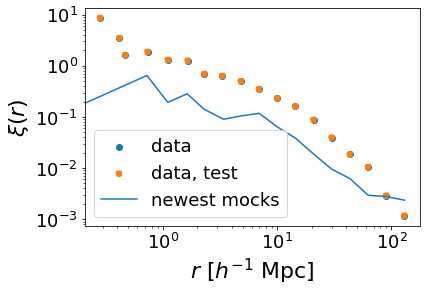

In [68]:
plt.scatter(ravg_data, cf_data, label = 'data')
plt.scatter(ravg_data_test, cf_data_test, label = 'data, test', linestyle = '--')
plt.plot(ravg_mock, cf_mock, label = 'newest mocks')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.ylim(-1,)
plt.legend()
plt.show()

### Average the mocks

In [69]:
cf_mocks, ravg_mocks = [], []
for i in range(1,21):
    
    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, '$Gaia$-$unWISE$ Quasar Catalog', G_lo, 
                                                                                           fn_sello, plot = False, mask = mask)
    cf_mock_i, ravg_mock_i = quaia.xi_r(tab_gcatlo_i[mask_gcatlo_i], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask_i, 
                                    pixel_indices_randlo_mask, N_gcatlo_mask_i, N_randlo_mask, RR_counts, correction, rbins = rbins, mask = mask)
    cf_mocks.append(cf_mock_i)
    ravg_mocks.append(ravg_mock_i)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra

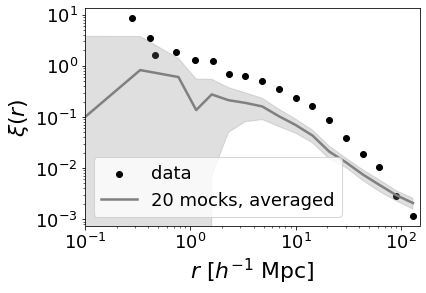

In [70]:
plt.scatter(ravg_data, cf_data, label = 'data', color = 'black')

# for i in range(len(cf_mocks)-1):
#         plt.plot(ravg_mocks[i], cf_mocks[i], color = 'red', alpha = 0.25)
# plt.plot(ravg_mocks[-1], cf_mocks[-1], color = 'red', label = '10 mocks', alpha = 0.25)

cf_mocks_mean = np.mean(cf_mocks, axis = 0)
ravg_mocks_mean = np.mean(ravg_mocks, axis = 0)
yerr = np.std(cf_mocks, axis = 0)
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '20 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
# plt.legend()
plt.show()

### Compare to https://arxiv.org/abs/2506.05612
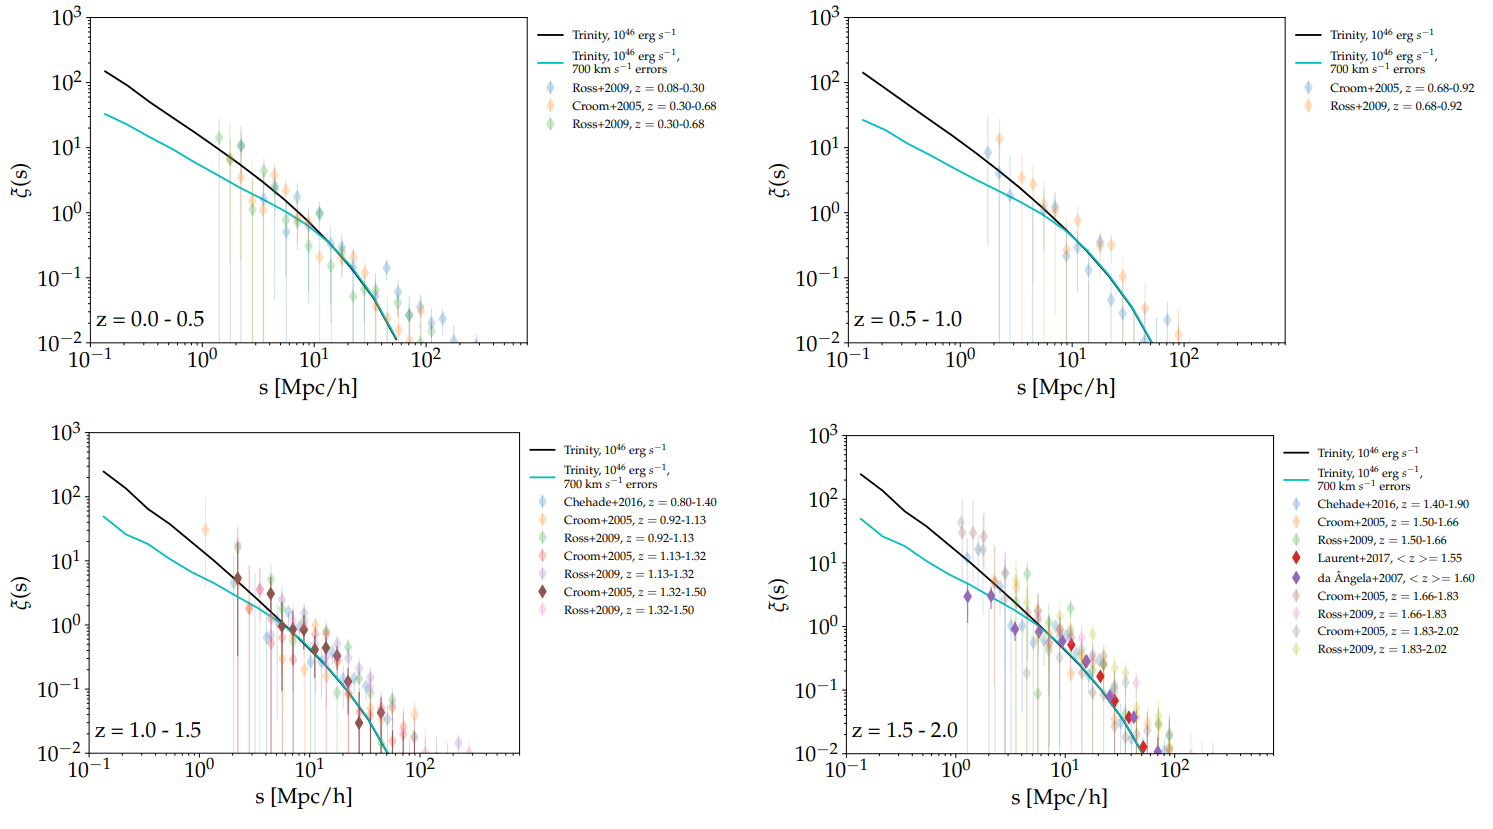

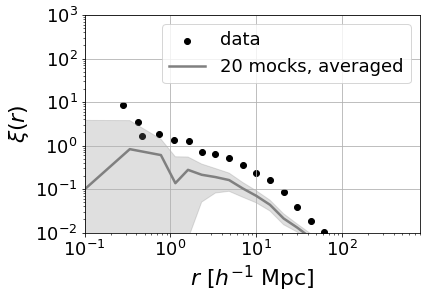

In [71]:
plt.scatter(ravg_data, cf_data, label = 'data', color = 'black')

# for i in range(len(cf_mocks)-1):
#         plt.plot(ravg_mocks[i], cf_mocks[i], color = 'red', alpha = 0.5)
# plt.plot(ravg_mocks[-1], cf_mocks[-1], color = 'red', label = '10 mocks', alpha = 0.5)

cf_mocks_mean = np.mean(cf_mocks, axis = 0)
yerr = np.std(cf_mocks, axis = 0)
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '20 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-1, 8e2)
plt.ylim(1e-2, 1e3)
plt.legend()
plt.grid()
plt.show()

## Check impact of masking

In [103]:
import importlib
importlib.reload(quaia)

<module 'quaia' from '/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py'>

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
2.8677088084770084 17.0 9.421527461015328


/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py:58: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


755850 [ True  True  True ...  True  True  True]
Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
2.480954198739738 17.0 9.679363867506842


/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py:58: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


744834 [ True  True  True ...  True  True  True]
Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
0.2812582096220524 16.0 10.840511579570999


/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py:58: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


660631 [ True  True  True ...  True  True  True]
Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
0.2766828634345089 6.0 11.446634273130982


/mnt/c/Users/Mahlet Shiferaw/Documents/Code/quaia_bias/notebooks/quaia.py:58: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


530364 [ True  True  True ... False False False]


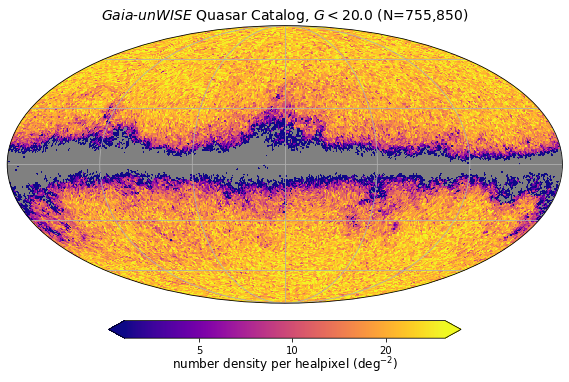

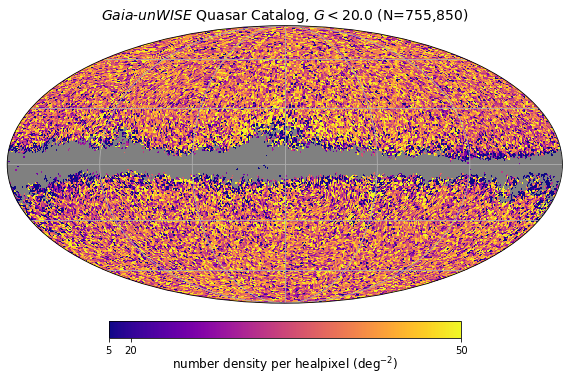

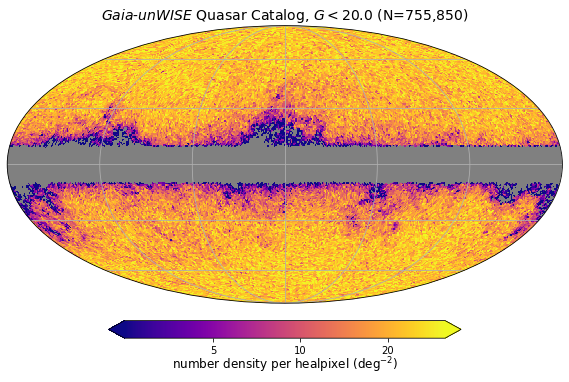

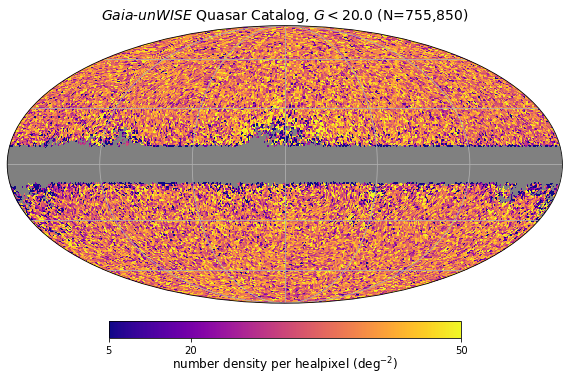

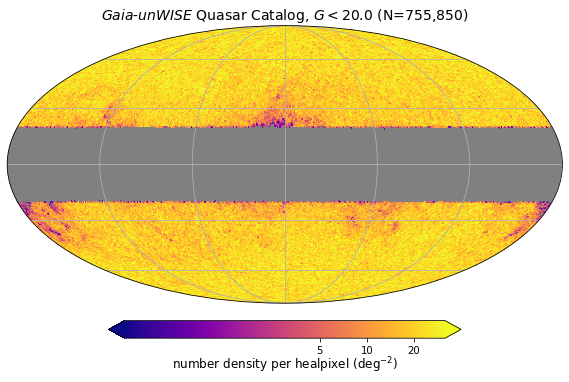

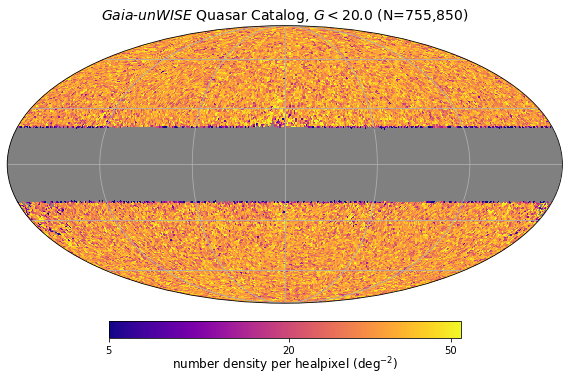

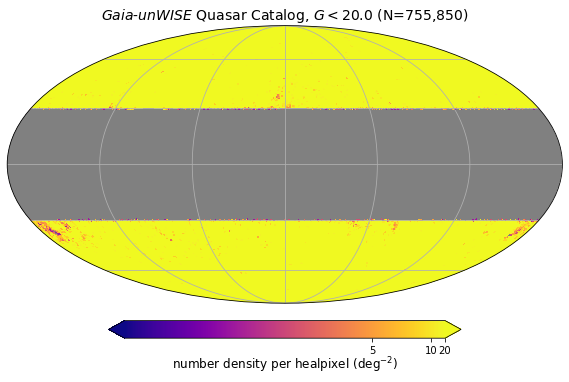

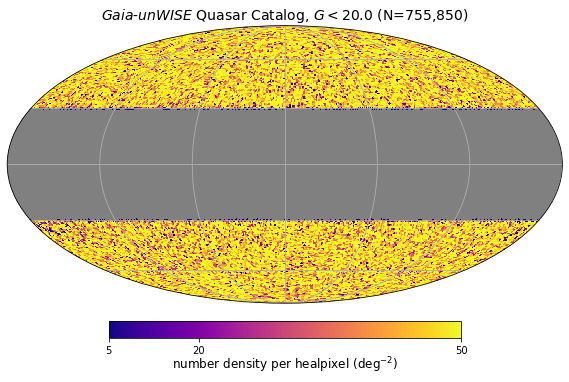

In [72]:
cf_data_b_array, ravg_data_b_array  = [], []
b_array = [0, 10, 20, 30]
fac_stdev_array = [1.5, 1.5, 1.45, 0.5] #1.45, 0.5
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', '$Gaia$-$unWISE$ Quasar Catalog', G_lo, fn_sello, 
                                                                mask = b_array[i], fac_stdev = fac_stdev_array[i])

    print(N_datalo_b, mask_datalo_b)
    mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, mask = b_array[i])
    
    pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    cf_data_b, ravg_data_b = quaia.xi_r(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], selfunc_lo, pixel_indices_datalo_b, 
                                        pixel_indices_randlo_b, N_datalo_b, N_randlo_b, None, correction, rbins = rbins, mask = b_array[i])
    cf_data_b_array.append(cf_data_b)
    ravg_data_b_array.append(ravg_data_b)

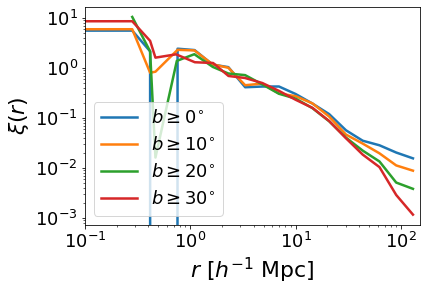

In [73]:
for i in range(len(b_array)):
    plt.plot(ravg_data_b_array[i], cf_data_b_array[i], label = '$b\geq{:d}^{{\circ}}$'.format(b_array[i]),linewidth = 2.5)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

# Questions
- why are npairs higher for lower pimax?
- negative wp? due to DR? bad?
- why do they use hubble distance if z is not << 1?
- does wp still get rid of RSDs if we are integrating to pimax and not infinity?
- why does xi_r calculation change every time i run it? --> because of regenerating z's! should it fluctuate that much?
- is it ok that cartesian coordinates go from -x/2 to x/2? --> no?

## Check if coord bounds matter

In [ ]:
from __future__ import print_function
import numpy as np
from os.path import dirname, abspath, join as pjoin
import Corrfunc
from Corrfunc.theory.DD import DD

rmin = 0.1
rmax = 15.0
nbins = 10
bins = np.linspace(rmin, rmax, nbins + 1)

N = 10000
boxsize = 420.0
nthreads = 4
autocorr = 1
seed = 42
np.random.seed(seed)
periodic = True
box_min, box_max = 0, boxsize
X = np.random.uniform(box_min, box_max, N)
Y = np.random.uniform(box_min, box_max, N)
Z = np.random.uniform(box_min, box_max, N)
weights = np.ones_like(X)
DD_counts = DD(autocorr, nthreads, bins, X, Y, Z, boxsize=boxsize, periodic = periodic)
for r in DD_counts: print("{0:10.6f} {1:10.6f} {2:10.6f} {3:10d} {4:10.6f}".
                        format(r['rmin'], r['rmax'], r['ravg'],
                        r['npairs'], r['weightavg'])) 

In [103]:
rand_N = 3*N
rand_X = np.random.uniform(box_min, box_max, rand_N)
rand_Y = np.random.uniform(box_min, box_max, rand_N)
rand_Z = np.random.uniform(box_min, box_max, rand_N)

autocorr = 0
DR_counts = DD(autocorr, nthreads, bins,
               X, Y, Z, periodic = periodic, 
               X2=rand_X, Y2=rand_Y, Z2=rand_Z, boxsize=boxsize)
autocorr = 1
RR_counts = DD(autocorr, nthreads, bins, rand_X, rand_Y, rand_Z, periodic = periodic,
               boxsize=boxsize)
cf = convert_3d_counts_to_cf(N, N, rand_N, rand_N,
                             DD_counts, DR_counts,
                             DR_counts, RR_counts)
for xi in cf: print("{0:10.6f}".format(xi))

 -0.345794
 -0.325073
  0.051558
 -0.036533
  0.084086
 -0.048341
  0.014120
 -0.008649
  0.039119
  0.022772
